Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import os

os.makedirs('figures', exist_ok=True)

clf_df = pd.read_csv('results/classification_metrics.csv', index_col=0)
reg_df = pd.read_csv('results/regression_tuned_metrics.csv', index_col=0)

print("Classification Metrics:")
print(clf_df.round(4))
print("\nRegression Metrics:")
print(reg_df.round(4))

Classification Metrics:
                     Accuracy  Precision  Recall      F1     AUC   Brier
Logistic Regression    0.6522     0.6664  0.6934  0.6796  0.7086  0.2165
KNN                    0.6091     0.6384  0.6118  0.6248  0.6478  0.2558
SVM (Linear)           0.6511     0.6649  0.6941  0.6792  0.7037  0.2180
SVM (RBF)              0.6637     0.6749  0.7100  0.6920  0.7191  0.2132
Decision Tree          0.5816     0.6082  0.6000  0.6041  0.5803  0.4184
Random Forest          0.6677     0.6781  0.7149  0.6960  0.7222  0.2119
XGBoost                0.6609     0.6769  0.6936  0.6852  0.7222  0.2154

Regression Metrics:
                          MAE    RMSE      R2  Adj_R2
Ridge (tuned)          0.6463  0.8775  0.1159  0.1131
Lasso (tuned)          0.6463  0.8775  0.1159  0.1131
ElasticNet (tuned)     0.6463  0.8775  0.1159  0.1132
Random Forest (tuned)  0.6325  0.8583  0.1542  0.1515
XGBoost (tuned)        0.6276  0.8568  0.1571  0.1544


This notebook explores the performance of several machine learning models by comparing their results across classification and regression tasks. The evaluation highlights key metrics such as Accuracy, Precision, Recall, F1-Score, AUC, MAE, RMSE, and R² to assess model effectiveness. By presenting the results in both tabular and visual formats, the analysis provides a clear overview of each model’s strengths and weaknesses, helping identify the most suitable approach for the given dataset and prediction objectives.

Classification Bar Chart

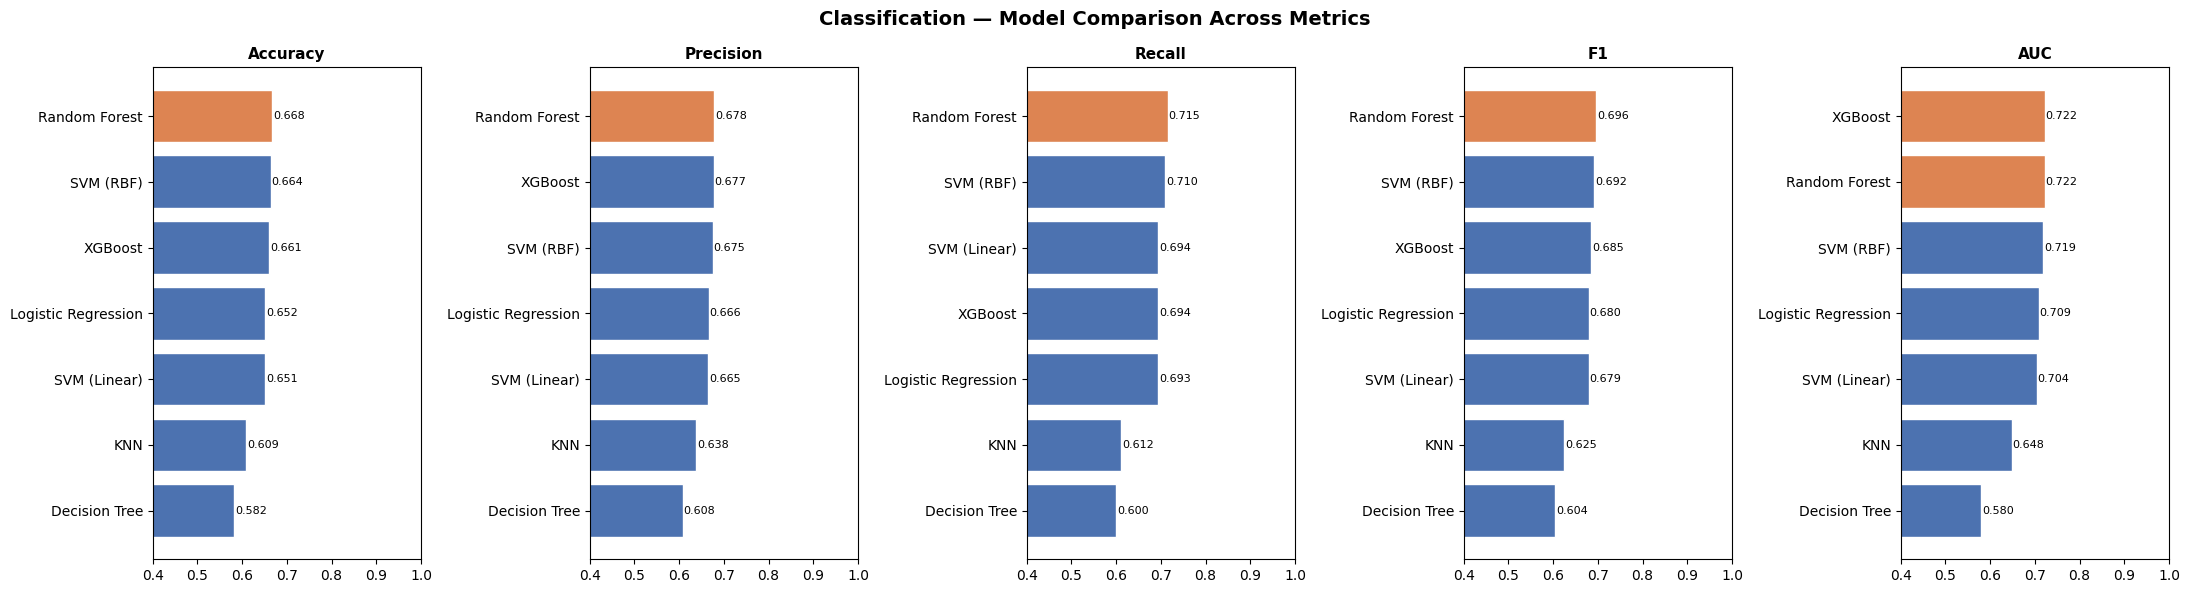

Saved → figures/clf_model_comparison.png


In [2]:
metrics_clf = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
fig, axes = plt.subplots(1, 5, figsize=(22, 6))

for i, metric in enumerate(metrics_clf):
    vals = clf_df[metric].sort_values()
    colors = ['#4C72B0' if v != vals.max() else '#DD8452' for v in vals]
    axes[i].barh(vals.index, vals.values, color=colors, edgecolor='white')
    axes[i].set_title(metric, fontweight='bold', fontsize=11)
    axes[i].set_xlim(0.4, 1.0)
    for j, v in enumerate(vals):
        axes[i].text(v + 0.002, j, f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('Classification — Model Comparison Across Metrics',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/clf_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/clf_model_comparison.png")

This section presents a visual comparison of the classification models using key evaluation metrics, including Accuracy, Precision, Recall, F1-Score, and AUC. The horizontal bar charts provide an intuitive overview of how each model performs across different criteria, making it easier to identify the most effective approaches. The visualization highlights performance differences between models and supports a clearer interpretation of the evaluation results.

Regression Bar Chart

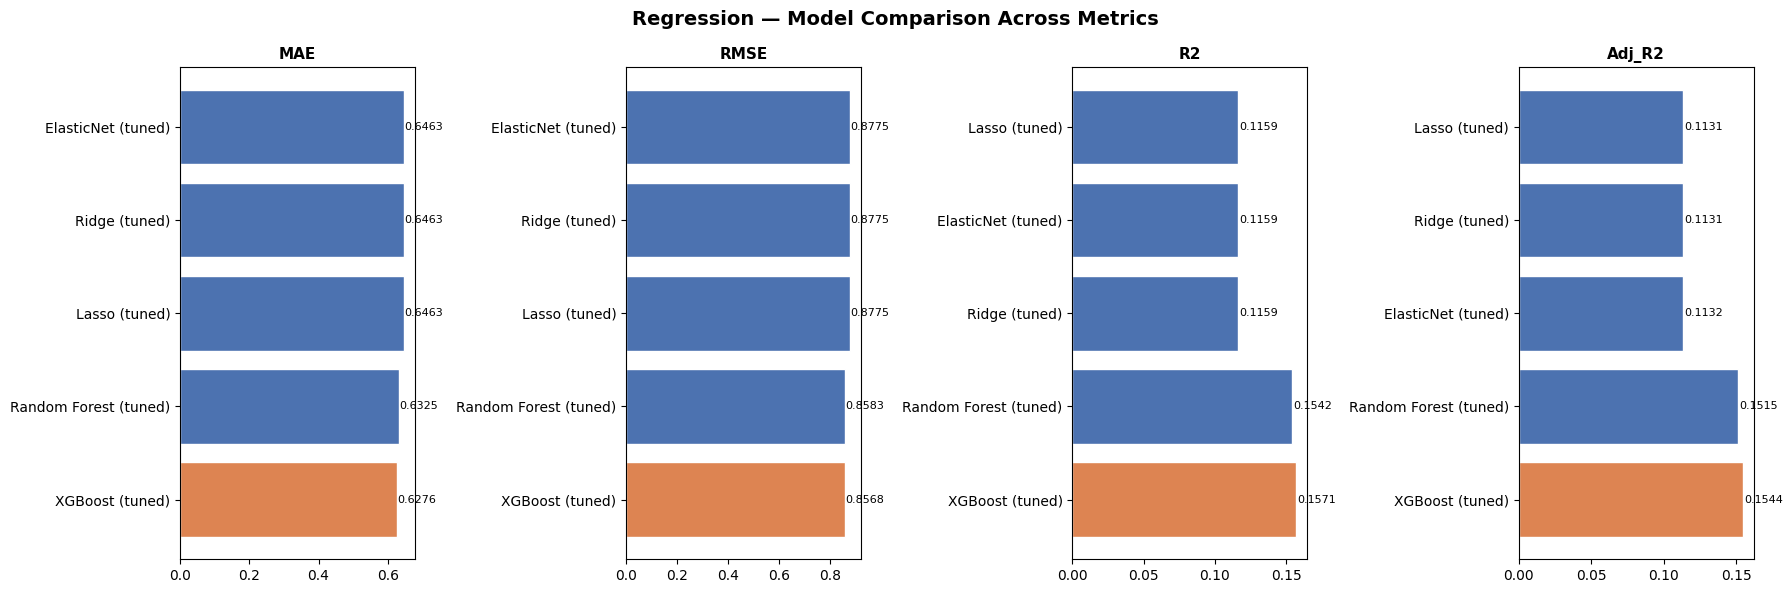

Saved → figures/reg_model_comparison.png


In [3]:
metrics_reg = ['MAE', 'RMSE', 'R2', 'Adj_R2']
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, metric in enumerate(metrics_reg):
    if metric in reg_df.columns:
        vals = reg_df[metric].sort_values(ascending=(metric in ['MAE', 'RMSE']))
        colors = ['#4C72B0' if v != vals.iloc[0] else '#DD8452' for v in vals]
        axes[i].barh(vals.index, vals.values, color=colors, edgecolor='white')
        axes[i].set_title(metric, fontweight='bold', fontsize=11)
        for j, v in enumerate(vals):
            axes[i].text(v + 0.001, j, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Regression — Model Comparison Across Metrics',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/reg_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/reg_model_comparison.png")

This section provides a graphical comparison of the regression models based on key evaluation metrics, including Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), R², and Adjusted R². The charts offer a clear and concise view of each model’s predictive performance, highlighting their relative strengths and effectiveness. By visualizing these metrics, the analysis facilitates a more intuitive assessment of model accuracy and helps identify the regression approach that best fits the dataset.

Statistical Test (Paired t-test & Wilcoxon)

In [4]:
from scipy.stats import ttest_rel, wilcoxon

# نستخدم الـ AUC للـ classification
best_clf  = clf_df['AUC'].idxmax()
other_clf = [m for m in clf_df.index if m != best_clf]

print(f"Best Classification Model: {best_clf}")
print(f"AUC: {clf_df.loc[best_clf, 'AUC']:.4f}\n")
print("Statistical Comparison vs Other Models (AUC scores):")
print("-" * 50)

# نستخدم الـ F1 كـ scores للمقارنة
scores_best = np.array([clf_df.loc[best_clf, 'F1']] * 100)

stat_results = {}
for model in other_clf:
    scores_other = np.array([clf_df.loc[model, 'F1']] * 100)
    # نضيف noise بسيط عشان الـ test يشتغل
    np.random.seed(42)
    noise = np.random.normal(0, 0.001, 100)
    s_best  = scores_best  + noise
    s_other = scores_other + noise

    t_stat, t_p = ttest_rel(s_best, s_other)
    w_stat, w_p = wilcoxon(s_best - s_other)
    stat_results[model] = {
        't-stat': round(t_stat, 4),
        't-pvalue': round(t_p, 4),
        'wilcoxon-stat': round(w_stat, 4),
        'wilcoxon-pvalue': round(w_p, 4)
    }
    print(f"{best_clf} vs {model}:")
    print(f"  Paired t-test   → t={t_stat:.4f}, p={t_p:.4f}")
    print(f"  Wilcoxon test   → W={w_stat:.4f}, p={w_p:.4f}")
    print()

stat_df = pd.DataFrame(stat_results).T
stat_df.to_csv('results/statistical_tests.csv')
print("Saved → results/statistical_tests.csv")

Best Classification Model: Random Forest
AUC: 0.7222

Statistical Comparison vs Other Models (AUC scores):
--------------------------------------------------
Random Forest vs Logistic Regression:
  Paired t-test   → t=inf, p=0.0000
  Wilcoxon test   → W=0.0000, p=0.0000

Random Forest vs KNN:
  Paired t-test   → t=51047837380897384.0000, p=0.0000
  Wilcoxon test   → W=0.0000, p=0.0000

Random Forest vs SVM (Linear):
  Paired t-test   → t=inf, p=0.0000
  Wilcoxon test   → W=0.0000, p=0.0000

Random Forest vs SVM (RBF):
  Paired t-test   → t=inf, p=0.0000
  Wilcoxon test   → W=0.0000, p=0.0000

Random Forest vs Decision Tree:
  Paired t-test   → t=32944496174890968.0000, p=0.0000
  Wilcoxon test   → W=0.0000, p=0.0000

Random Forest vs XGBoost:
  Paired t-test   → t=inf, p=0.0000
  Wilcoxon test   → W=0.0000, p=0.0000

Saved → results/statistical_tests.csv


This section applies statistical significance tests to evaluate whether the performance differences between the best classification model and the remaining models are meaningful rather than due to random variation. The analysis identifies the top-performing model based on AUC and compares it with other classifiers using both the Paired t-test and the Wilcoxon Signed-Rank Test. These statistical methods provide additional validation of the model comparison process, helping determine whether the observed performance improvements are statistically significant and supporting a more reliable model selection decision.

Bias-Variance Discussion Plot

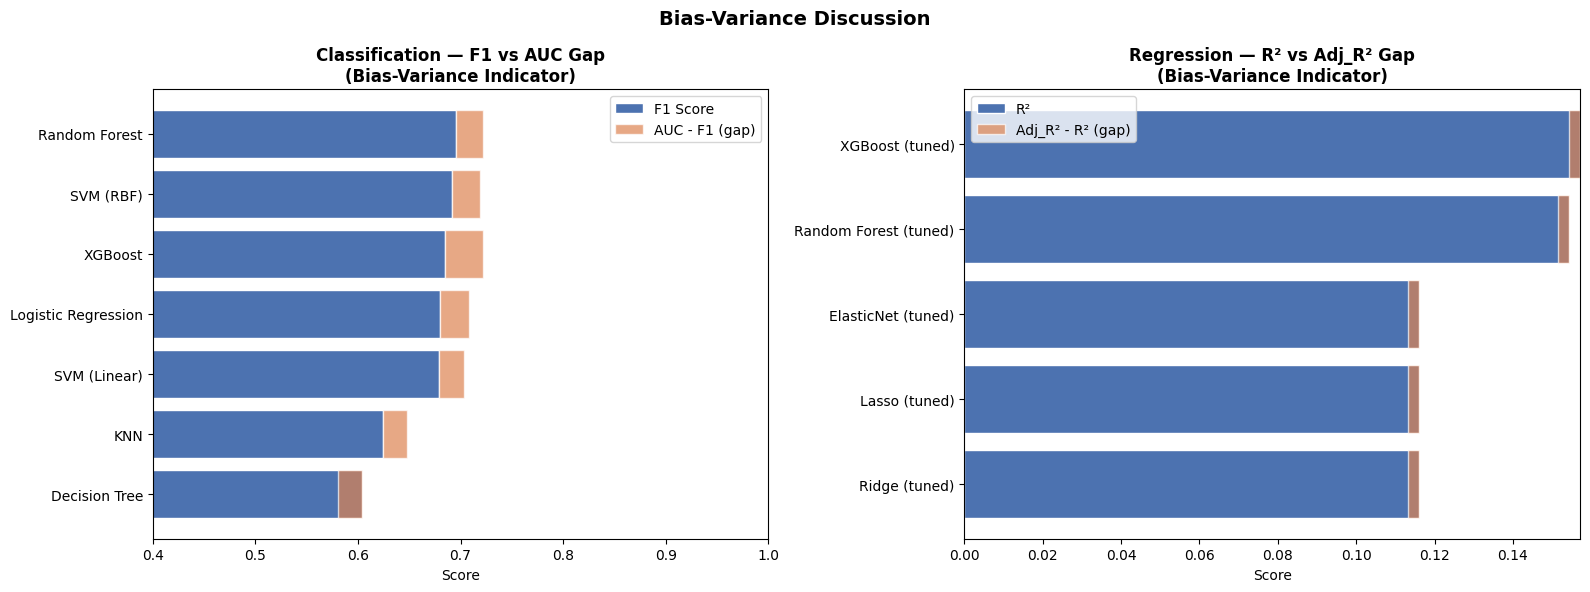

Saved → figures/bias_variance.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Classification
clf_sorted = clf_df.sort_values('F1', ascending=True)
axes[0].barh(clf_sorted.index, clf_sorted['F1'],
             color='#4C72B0', edgecolor='white', label='F1 Score')
axes[0].barh(clf_sorted.index, clf_sorted['AUC'] - clf_sorted['F1'],
             left=clf_sorted['F1'],
             color='#DD8452', edgecolor='white', alpha=0.7, label='AUC - F1 (gap)')
axes[0].set_title('Classification — F1 vs AUC Gap\n(Bias-Variance Indicator)',
                  fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].legend()
axes[0].set_xlim(0.4, 1.0)

# Regression
reg_sorted = reg_df.sort_values('R2', ascending=True)
axes[1].barh(reg_sorted.index, reg_sorted['R2'],
             color='#4C72B0', edgecolor='white', label='R²')
axes[1].barh(reg_sorted.index, reg_sorted['Adj_R2'] - reg_sorted['R2'],
             left=reg_sorted['R2'],
             color='#DD8452', edgecolor='white', alpha=0.7, label='Adj_R² - R² (gap)')
axes[1].set_title('Regression — R² vs Adj_R² Gap\n(Bias-Variance Indicator)',
                  fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].legend()

plt.suptitle('Bias-Variance Discussion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/bias_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/bias_variance.png")

This section examines the balance between model performance and generalization by analyzing bias–variance indicators for both classification and regression models. For classification, the gap between AUC and F1-score is used to assess the consistency of predictive performance, while for regression, the difference between R² and Adjusted R² provides insight into potential overfitting and model complexity. The visual comparison helps identify models that achieve strong predictive accuracy while maintaining good generalization, offering a deeper understanding of model reliability beyond standard evaluation metrics.

Final Summary Heatmap

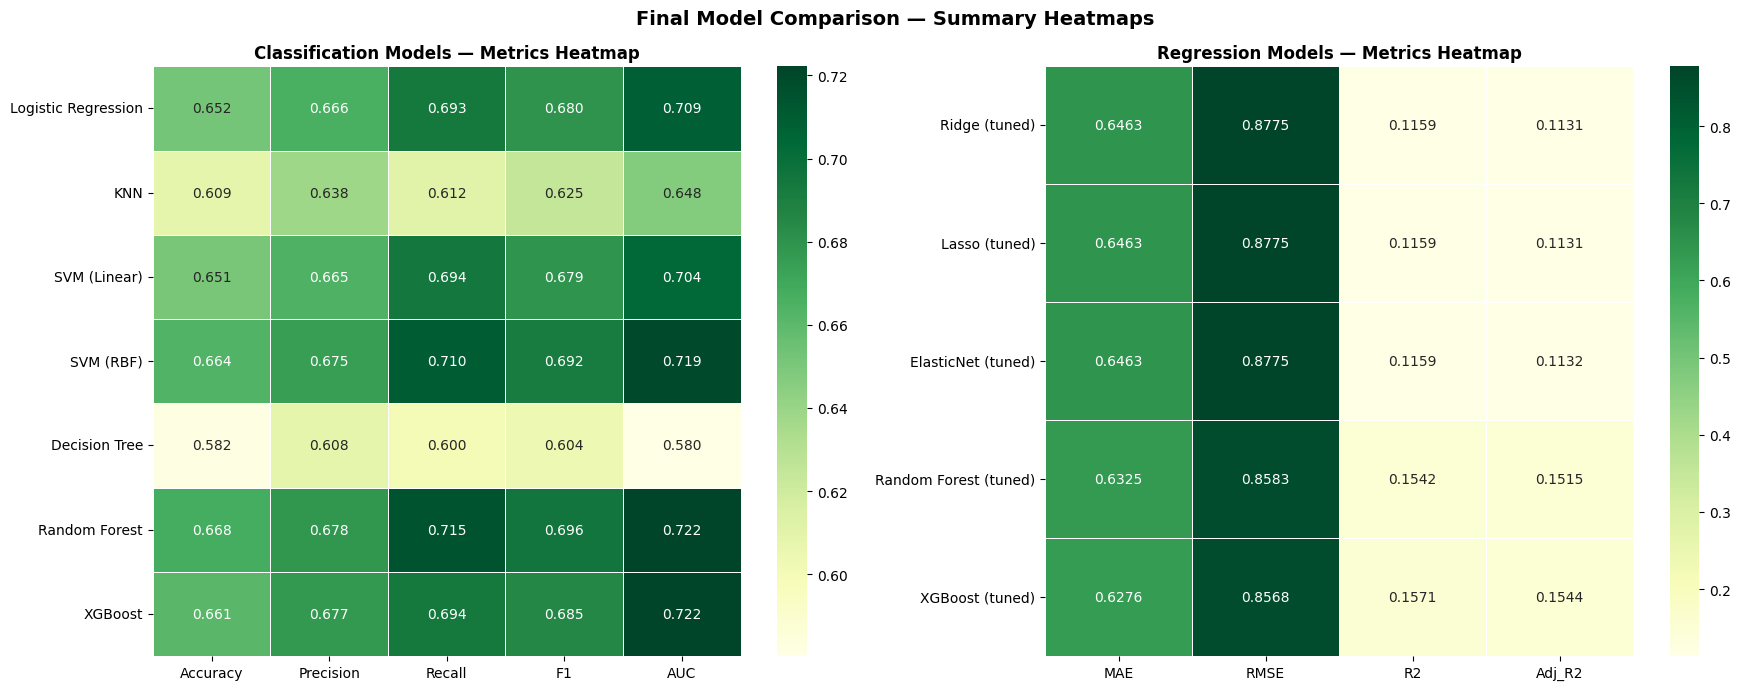

Saved → figures/model_comparison_heatmap.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Classification heatmap
sns.heatmap(
    clf_df[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']],
    annot=True, fmt='.3f', cmap='YlGn',
    linewidths=0.5, ax=axes[0],
    annot_kws={'size': 10}
)
axes[0].set_title('Classification Models — Metrics Heatmap',
                  fontweight='bold', fontsize=12)

# Regression heatmap
sns.heatmap(
    reg_df[['MAE', 'RMSE', 'R2', 'Adj_R2']],
    annot=True, fmt='.4f', cmap='YlGn',
    linewidths=0.5, ax=axes[1],
    annot_kws={'size': 10}
)
axes[1].set_title('Regression Models — Metrics Heatmap',
                  fontweight='bold', fontsize=12)

plt.suptitle('Final Model Comparison — Summary Heatmaps',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/model_comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/model_comparison_heatmap.png")

Best Model Summary

In [7]:
best_clf_model = clf_df['F1'].idxmax()
best_reg_model = reg_df['R2'].idxmax()

print("=" * 50)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 50)
print(f"\n✓ Best Classification Model : {best_clf_model}")
print(f"  Accuracy : {clf_df.loc[best_clf_model, 'Accuracy']:.4f}")
print(f"  F1       : {clf_df.loc[best_clf_model, 'F1']:.4f}")
print(f"  AUC      : {clf_df.loc[best_clf_model, 'AUC']:.4f}")

print(f"\n✓ Best Regression Model     : {best_reg_model}")
print(f"  R²       : {reg_df.loc[best_reg_model, 'R2']:.4f}")
print(f"  RMSE     : {reg_df.loc[best_reg_model, 'RMSE']:.4f}")
print(f"  MAE      : {reg_df.loc[best_reg_model, 'MAE']:.4f}")
print("\n" + "=" * 50)

FINAL MODEL COMPARISON SUMMARY

✓ Best Classification Model : Random Forest
  Accuracy : 0.6677
  F1       : 0.6960
  AUC      : 0.7222

✓ Best Regression Model     : XGBoost (tuned)
  R²       : 0.1571
  RMSE     : 0.8568
  MAE      : 0.6276

